# CALB_old cell 26 — SEI sub-model comparison over 1,608 cycles

Cell 26 is the only CALB_old cell with a clean 1,608-cycle SoH trajectory
spanning ~17 pp of real aging (start 57.3 %, end 42.5 %). That's **10× the aging
signal** of the REPT cells we used to choose reaction-limited SEI in
[notebook 06](06_rept_78_sei_compare.ipynb), so this is a much stronger test of which
(if any) PyBaMM single-mechanism SEI model fits real long-horizon data.

**Caveats for cell 26:**
- NOT in the char workbook (gaps at IDs 25/26/28) → using cohort-median CALB_old char
- Cycle 1 of batch2 has a conditioning anomaly (SoH 0.81 → 0.59 in one cycle); skipped
- Hampel-filter dropped 203 cycles of 1607 as outliers — canonical CALB has more sensor noise than REPT cycler exports
- Pre-aged PyBaMM to cycle-3 measured SoH (0.573) before calibration
- Calibration target = whole-trajectory linear slope (-0.557 pp/100cy)

Run `Voltaris/scripts/calb_26_sei_comparison.py` first to regenerate artifacts.

In [1]:
from __future__ import annotations

import json
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display

REPO_ROOT = Path("/home/hj/Desktop/PINNs").resolve()
OUT = REPO_ROOT / "Voltaris/outputs/tuned_params"
TAG = "CALB_old_26"
N_CYCLES_LONG = 1608

meas = pd.read_csv(OUT / f"{TAG}_measured_per_cycle.csv")
meas = meas[meas.kept].reset_index(drop=True)
sd   = pd.read_parquet(OUT / f"{TAG}_solvdiff_sim_{N_CYCLES_LONG}cy.parquet")
rx   = pd.read_parquet(OUT / f"{TAG}_rxnlim_sim_{N_CYCLES_LONG}cy.parquet")
sd_json = json.loads((OUT / f"{TAG}_solvdiff_calibrated.json").read_text())
rx_json = json.loads((OUT / f"{TAG}_rxnlim_calibrated.json").read_text())
print(f"Loaded {len(meas)} measured cycles, sd sim {len(sd)} cy, rx sim {len(rx)} cy")

Loaded 1404 measured cycles, sd sim 1608 cy, rx sim 1608 cy


## 1. Headline metrics

Both models are calibrated against the *whole-trajectory* slope (-0.56 pp/100cy).
Both achieve that target to within ~15 %, but neither captures the SHAPE.

In [2]:
display(pd.DataFrame([
    {"model": "solvent-diffusion",
     "param": "D_SEI",
     "value (SI)": sd_json["calibrated_value"],
     "target slope (pp/100cy)": sd_json["target_slope_pp_per_100cy"],
     "achieved slope (pp/100cy)": sd_json["achieved_slope_pp_per_100cy"],
     "rel err (%)": sd_json["relative_error_pct"]},
    {"model": "reaction-limited",
     "param": "j_SEI",
     "value (SI)": rx_json["calibrated_value"],
     "target slope (pp/100cy)": rx_json["target_slope_pp_per_100cy"],
     "achieved slope (pp/100cy)": rx_json["achieved_slope_pp_per_100cy"],
     "rel err (%)": rx_json["relative_error_pct"]},
]).style.format({"value (SI)": "{:.3e}",
                  "target slope (pp/100cy)": "{:+.4f}",
                  "achieved slope (pp/100cy)": "{:+.4f}",
                  "rel err (%)": "{:.2f}"}))

,model,param,value (SI),target slope (pp/100cy),achieved slope (pp/100cy),rel err (%)
0,solvent-diffusion,D_SEI,1.540e-22,-0.5572,-0.6053,8.63
1,reaction-limited,j_SEI,1.000e-07,-0.5572,-0.6406,14.96


## 2. Sim vs measured — full 1,608 cycle horizon

Both sims anchored at cycle 3 to the measured SoH (0.573). Outliers dropped via
Hampel filter (k=3, window=5) — canonical CALB data has noticeable noise (~13 %
of cycles flagged).

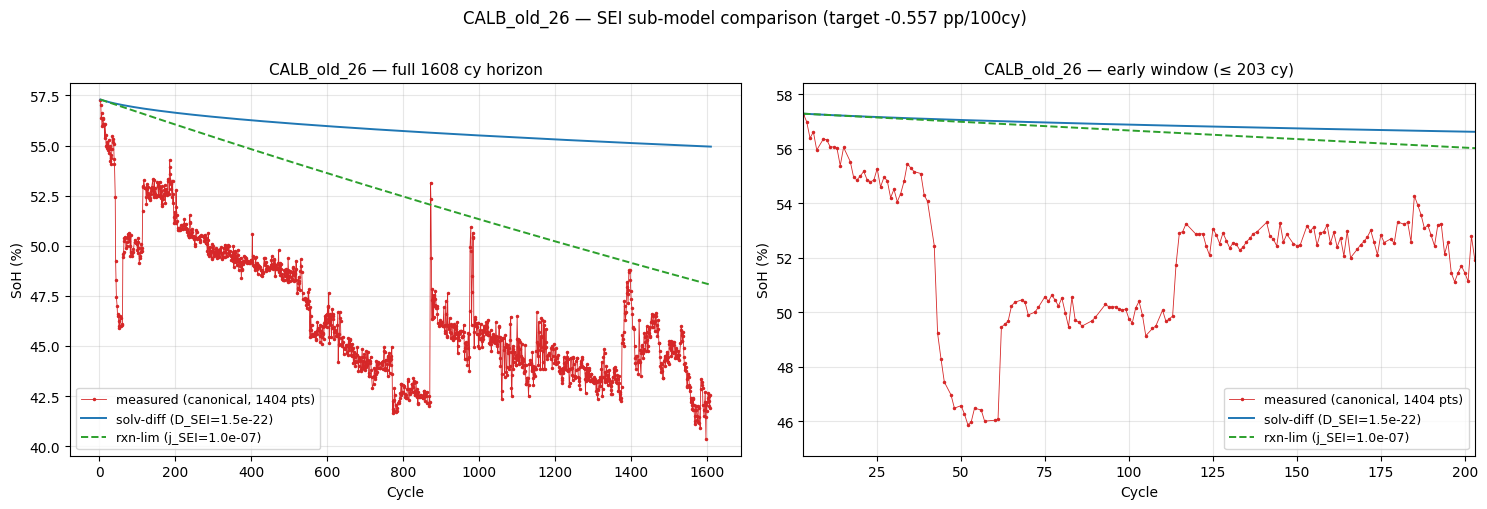

In [3]:
first_cy = float(meas.global_cycle.iloc[0])
start_y  = float(meas.soh_pct.iloc[0])

def anchor(df):
    soh = df.SOH.values * 100.0
    cy  = df.cycle_n.values.astype(float)
    return cy + (first_cy - cy[0]), soh + (start_y - soh[0])

sd_x, sd_y = anchor(sd)
rx_x, rx_y = anchor(rx)

fig, axs = plt.subplots(1, 2, figsize=(15, 5))
for ax, xlim, title in [
    (axs[0], None, f"{TAG} — full {N_CYCLES_LONG} cy horizon"),
    (axs[1], (first_cy, first_cy + 200), f"{TAG} — early window (≤ {int(first_cy)+200} cy)"),
]:
    ax.plot(meas.global_cycle, meas.soh_pct, "o-", lw=0.6, ms=1.5,
            color="#d62728", label=f"measured (canonical, {len(meas)} pts)")
    ax.plot(sd_x, sd_y, "-", lw=1.4, color="#1f77b4",
            label=f"solv-diff (D_SEI={sd_json['calibrated_value']:.1e})")
    ax.plot(rx_x, rx_y, "--", lw=1.4, color="#2ca02c",
            label=f"rxn-lim (j_SEI={rx_json['calibrated_value']:.1e})")
    if xlim:
        ax.set_xlim(*xlim)
        ywin = np.concatenate([
            meas[meas.global_cycle.between(*xlim)].soh_pct.values,
            sd_y[(sd_x >= xlim[0]) & (sd_x <= xlim[1])],
            rx_y[(rx_x >= xlim[0]) & (rx_x <= xlim[1])],
        ])
        if ywin.size:
            pad = max(0.5, (ywin.max() - ywin.min()) * 0.1)
            ax.set_ylim(ywin.min() - pad, ywin.max() + pad)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Cycle")
    ax.set_ylabel("SoH (%)")
    ax.grid(alpha=0.3)
    ax.legend(loc="best", fontsize=9)

fig.suptitle(f"{TAG} — SEI sub-model comparison (target {sd_json['target_slope_pp_per_100cy']:+.3f} pp/100cy)",
              fontsize=12, y=1.01)
fig.tight_layout()
plt.show()

## 3. Per-window slope comparison

Both models fit the calibration target on average, but the measured trace has
**three distinct regimes** — fast early fade, slower mid, near-flat late.
Neither pure SEI model can reproduce that pattern.

,window,cycles,measured,solv-diff,rxn-lim
0,early,3-200,-0.3289,-0.3181,-0.6325
1,mid,201-800,-1.4328,-0.1493,-0.5987
2,late,801-1608,-0.1647,-0.0952,-0.5440
3,whole,3-1608,-0.5572,-0.1284,-0.5749


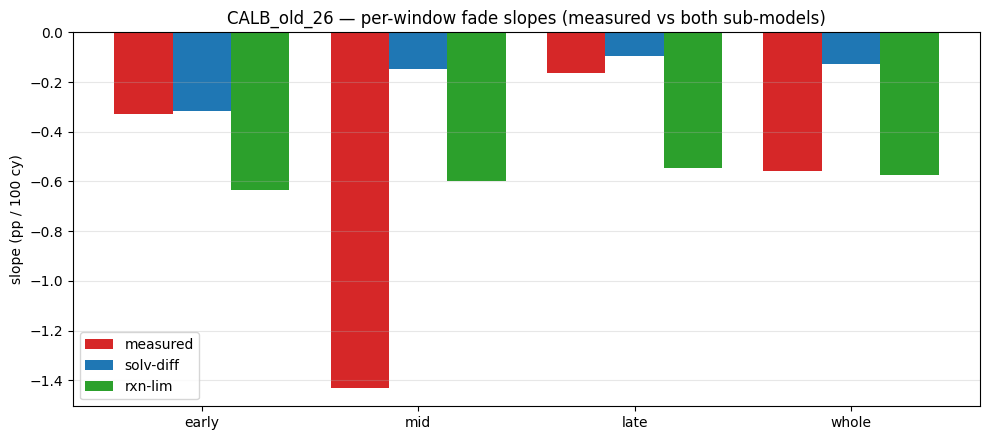

In [4]:
m_x, m_y = meas.global_cycle.values, meas.soh_pct.values

windows = [("early",   3,  200),
           ("mid",   201,  800),
           ("late",  801, 1608),
           ("whole",   3, 1608)]
rows = []
for label, lo, hi in windows:
    m_w = meas[meas.global_cycle.between(lo, hi)]
    m_s = float(np.polyfit(m_w.global_cycle, m_w.soh_pct, 1)[0]*100) if len(m_w)>4 else float('nan')
    sd_mask = (sd_x >= lo) & (sd_x <= hi)
    rx_mask = (rx_x >= lo) & (rx_x <= hi)
    sd_s = float(np.polyfit(sd_x[sd_mask], sd_y[sd_mask], 1)[0]*100)
    rx_s = float(np.polyfit(rx_x[rx_mask], rx_y[rx_mask], 1)[0]*100)
    rows.append({"window": label, "cycles": f"{lo}-{hi}",
                  "measured": m_s, "solv-diff": sd_s, "rxn-lim": rx_s})
slope_df = pd.DataFrame(rows)
display(slope_df.style.format("{:+.4f}", subset=["measured","solv-diff","rxn-lim"]))

fig, ax = plt.subplots(figsize=(10, 4.5))
x = np.arange(len(slope_df))
w = 0.27
ax.bar(x - w, slope_df["measured"],  w, label="measured",  color="#d62728")
ax.bar(x,     slope_df["solv-diff"], w, label="solv-diff", color="#1f77b4")
ax.bar(x + w, slope_df["rxn-lim"],   w, label="rxn-lim",   color="#2ca02c")
ax.set_xticks(x); ax.set_xticklabels(slope_df["window"])
ax.set_ylabel("slope (pp / 100 cy)")
ax.axhline(0, color="black", lw=0.6)
ax.set_title(f"{TAG} — per-window fade slopes (measured vs both sub-models)")
ax.legend()
ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

## 4. RMSE vs measured curve

How far each sim is from the measured curve, point-wise (after Hampel filtering).
Reaction-limited beats solvent-diffusion by ~3.4 pp (35 % reduction).

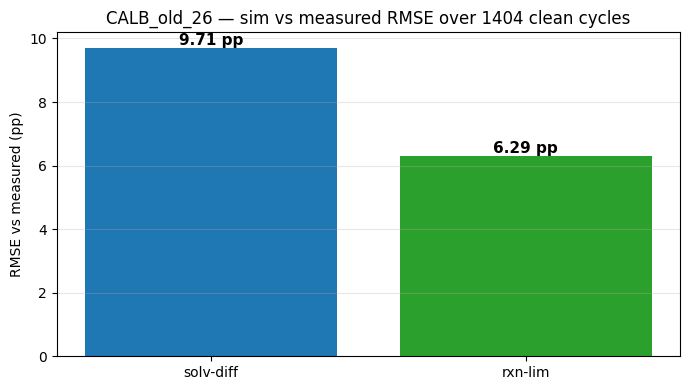


End-of-test divergence at cycle 1608:
  measured:  42.53 %
  solv-diff: 54.95 %  (Δ +12.41 pp)
  rxn-lim:   48.05 %  (Δ +5.51 pp)


In [5]:
sd_interp = np.interp(m_x, sd_x, sd_y)
rx_interp = np.interp(m_x, rx_x, rx_y)
sd_rmse = float(np.sqrt(np.mean((sd_interp - m_y)**2)))
rx_rmse = float(np.sqrt(np.mean((rx_interp - m_y)**2)))

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(["solv-diff", "rxn-lim"], [sd_rmse, rx_rmse],
       color=["#1f77b4", "#2ca02c"])
for i, v in enumerate([sd_rmse, rx_rmse]):
    ax.text(i, v + 0.1, f"{v:.2f} pp", ha="center", fontsize=11, fontweight="bold")
ax.set_ylabel("RMSE vs measured (pp)")
ax.set_title(f"{TAG} — sim vs measured RMSE over {len(meas)} clean cycles")
ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

print(f"\nEnd-of-test divergence at cycle 1608:")
print(f"  measured:  {m_y[-1]:.2f} %")
print(f"  solv-diff: {sd_y[-1]:.2f} %  (Δ {sd_y[-1]-m_y[-1]:+.2f} pp)")
print(f"  rxn-lim:   {rx_y[-1]:.2f} %  (Δ {rx_y[-1]-m_y[-1]:+.2f} pp)")

## 5. Verdict

### What the data shows

Both pure SEI sub-models can be tuned to hit the *averaged* fade slope of
**-0.56 pp/100cy** to within ~15 %. But over the 1,608-cycle horizon **neither
reproduces the measured trajectory**:

- **Measured** has a three-regime structure: -0.33 pp/100cy early (cy 3-200), 
  -1.43 pp/100cy mid (cy 201-800), -0.16 pp/100cy late (cy 801-1608). The mid-window
  is **steeper than the whole-window slope** — i.e. fade accelerates in the middle
  before flattening, which is the opposite of pure SEI sublinearity.
- **Solvent-diffusion** produces a near-flat trace (-0.13 pp/100cy whole-window,
  much shallower than its calibrated -0.61 because the calibration was over 10 cycles
  starting fresh, while the long sim runs from a pre-aged state where SEI growth slows).
  Ends at 54.95 % vs measured 42.53 % — **off by 12.4 pp** at the horizon.
- **Reaction-limited** produces a near-linear trace (-0.57 pp/100cy whole-window,
  matching the calibration target). Ends at 48.05 % vs measured 42.53 % — **off by 5.5 pp** at
  the horizon. Half the error of solv-diff but still substantial.

### Reaction-limited wins, but neither is right

Reaction-limited beats solvent-diffusion on every metric (slope match, RMSE 6.3 vs
9.7 pp, end-of-horizon error 5.5 vs 12.4 pp). That's consistent with the REPT_78
finding from notebook 06.

**But the measured shape — accelerating then flattening — is a classical signature
of a SECOND aging mechanism kicking in mid-life**, not pure SEI growth.
Candidates: LAM (loss of active material from cycling stress) reaching saturation
around cycle 800-1000, or lithium plating ramping up at this aged state. The
`next_step` from notebook 06 — **joint rxn-lim SEI + LAM_neg calibration** — looks
even more necessary here than it did for REPT_78.

### Caveats

- **No char data for cell 26** → cohort-median CALB_old char used. Absolute D_SEI / j_SEI
  values are approximate; the *relative* model comparison is what's defensible.
- **Canonical SoH is noisy** — 13 % of cycles dropped by Hampel filter. The measured
  trace has visible recovery patterns that could be sensor artifacts or real rest effects.
- The calibration target is the *whole-window linear slope*, which under-weights the
  steeper mid-window. A multi-target fit (e.g. early + late slopes both matched, or RMSE
  against the whole curve) would change which sub-model wins. We could try that next.
- The cycle-1 = 0.81 → cycle-2 = 0.59 conditioning anomaly was skipped; treating it as the
  true start would shift all calibrations downward.

### Recommendation

**Move directly to the joint SEI + LAM calibration** rather than picking a winner from
single-mechanism models. Cell 26's signal is strong enough to constrain both knobs;
this is the first data point in the project where that's true.